In [1]:
import sys
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

from pyproj import CRS, Transformer
from scipy.spatial.distance import pdist, squareform

import pyvista as pv

from scipy.spatial.distance import pdist, squareform
from scipy.interpolate import RBFInterpolator

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pd.__version__)

Python: 3.12.13 | packaged by conda-forge | (main, Aug 11 2026, 10:27:28) [GCC 14.4.0]
NumPy: 2.5.2
SciPy: 1.18.0
Pandas: 3.0.5


### Lets start with loading the data

In [2]:
#Defining path to file
path = "/mnt/c/Users/josem/OneDrive/Documents/Dummy_data/new_dummy_data3.csv" # r'/path' for windows

# using pandas pd.read_csv(path) I will load in the data
df = pd.read_csv(path)

### Now we will visualize the data in 3D

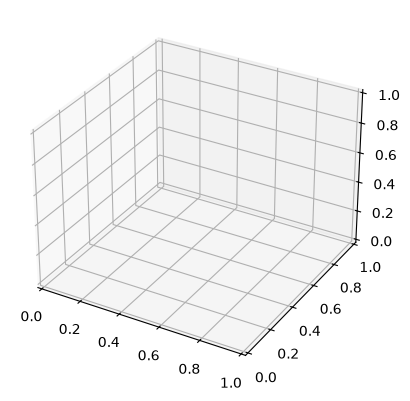

In [3]:
# Using matplotlib for now
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt

# defining figure and axis
fig = plt.figure()
ax = plt.axes(projection='3d')


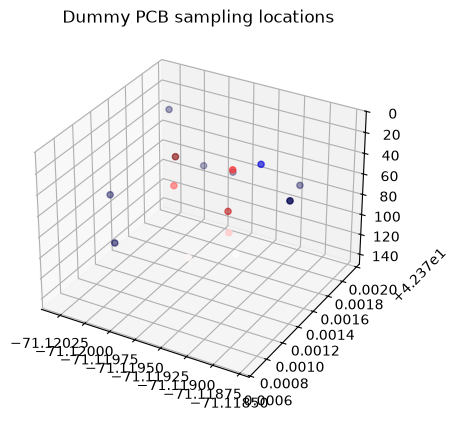

In [4]:
# assigning x,y,z to frame
fig = plt.figure()
ax = plt.axes(projection='3d')

x=df['long']
y=df['lat']
z=df['depth']
c=df['PCB']

ax.scatter(x, y, z,c=c, cmap='seismic')

ax.set_zlim(0,150)
ax.invert_zaxis()  # This flips the z-axis direction

ax.set_title('Dummy PCB sampling locations')

plt.show()

### Doing some prelimenary statistical stuff

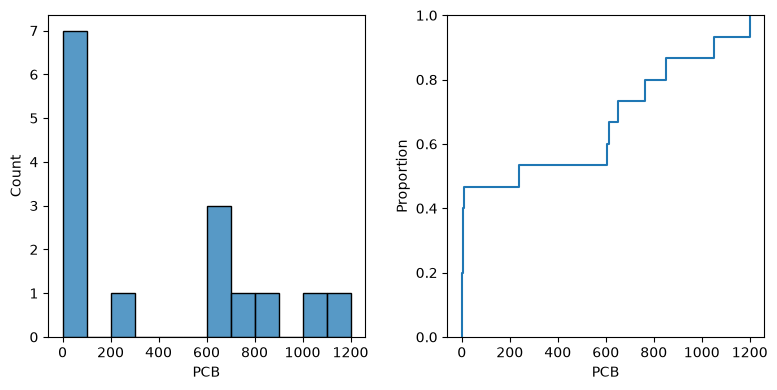

In [5]:
import seaborn as sns

contaminant = "PCB"

fig, axes = plt.subplots(1,2, figsize=(8, 4))

sns.histplot(
    data=df,
    x=contaminant,
    binwidth=100,
    ax=axes[0],
)

sns.ecdfplot(
    data=df,
    x=contaminant,
    ax=axes[1],
)

fig.tight_layout()
plt.show()

In [6]:
print(f"The minimum {contaminant} value  is: {df[contaminant].min():.2f}")
print(f"The maximum {contaminant} value  is: {df[contaminant].max():.2f}")
print(f"The median {contaminant}  value  is: {df[contaminant].median():.2f}")
print(f"The average {contaminant} value  is: {df[contaminant].mean():.2f}")
print(f"The standard deviation is: {df[contaminant].std():.2f}")

The minimum PCB value  is: 0.00
The maximum PCB value  is: 1200.00
The median PCB  value  is: 240.00
The average PCB value  is: 400.00
The standard deviation is: 437.02


Now log -transforming the data

In [7]:
df_log = df.copy()
df_log["PCB_log1p"] = np.log1p(df_log["PCB"])


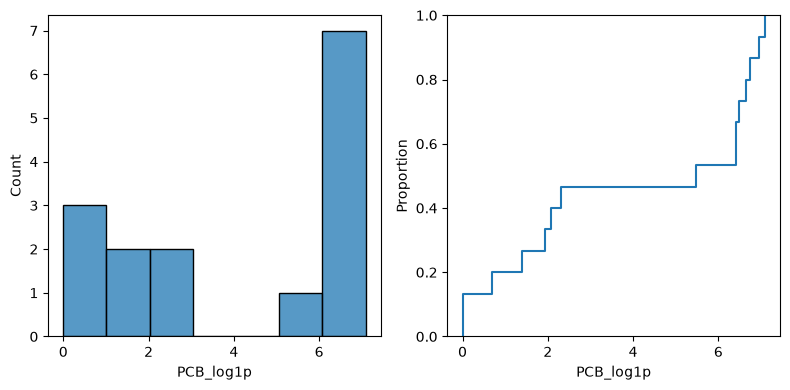

In [8]:
contaminant_log = "PCB_log1p"
fig, axes = plt.subplots(1,2, figsize=(8, 4))

sns.histplot(
    data=df_log,
    x=contaminant_log,
    binwidth=1,
    ax=axes[0],
)

sns.ecdfplot(
    data=df_log,
    x=contaminant_log,
    ax=axes[1],
)

fig.tight_layout()
plt.show()

In [9]:
print(f"The minimum {contaminant_log} value  is: {df_log[contaminant_log].min():.2f}")
print(f"The maximum {contaminant_log} value  is: {df_log[contaminant_log].max():.2f}")
print(f"The median {contaminant_log}  value  is: {df_log[contaminant_log].median():.2f}")
print(f"The average {contaminant_log} value  is: {df_log[contaminant_log].mean():.2f}")
print(f"The standard deviation is: {df_log[contaminant_log].std():.2f}")

The minimum PCB_log1p value  is: 0.00
The maximum PCB_log1p value  is: 7.09
The median PCB_log1p  value  is: 5.48
The average PCB_log1p value  is: 4.04
The standard deviation is: 2.85


### Determine the CRS and project the monitoring-well coordinates

Monitoring-well locations are often recorded as longitude and latitude. These are angular coordinates measured in degrees, not linear distances measured in feet or meters.

This becomes a serious problem for 3D modeling when the vertical coordinate—such as elevation, depth, or screened-interval elevation—is measured in meters or feet. If we interpolate directly using longitude, latitude, and elevation, the three coordinate axes have incompatible units:

$$
(\text{longitude in degrees},\ \text{latitude in degrees},\ \text{elevation in meters})
$$

A numerical interpolator generally treats these values as coordinates in one common distance system. It does not understand that one axis contains degrees while another contains meters.

One degree of latitude is approximately 111 kilometers. The distance represented by one degree of longitude varies with latitude and is approximately

$$
111\cos(\phi)\ \text{kilometers},
$$

where \(\phi\) is latitude. At approximately \(36.56^\circ\text{N}\), one degree of longitude represents about 89 kilometers.

Consequently, a seemingly small horizontal coordinate difference such as \(0.001^\circ\) may represent roughly 90–110 meters. Comparing that numerical difference directly with a vertical difference of 10 meters would badly distort the geometry used by the interpolator.

Before calculating distances or performing interpolation, we should therefore:

1. Identify the coordinate reference system (CRS) of the input data.
2. Transform longitude and latitude into an appropriate projected CRS.
3. Verify that the projected horizontal units are meters.
4. Convert vertical measurements into the same linear unit.
5. Document the meaning and vertical datum of the elevation values.

For this synthetic dataset, we assume that the input coordinates use WGS 84:

```python
source_crs = "EPSG:4326"
```

The wells are located near longitude $-105.61^\circ$ and latitude $36.56^\circ$ N. Therefore, UTM Zone 13N is an appropriate projected CRS for this local experiment:

```python
model_crs = "EPSG:32613"
```

After transformation, the modeling coordinates will have the form:

$$
(X\text{ in meters},\ Y\text{ in meters},\ Z\text{ in meters})
$$

This gives the numerical model a consistent geometric foundation. It does not yet determine how strongly vertical and horizontal separation should influence concentration. That requires an explicit hydrogeologic anisotropy model later. However, projection removes the fundamental error of mixing angular coordinates in degrees with vertical coordinates in linear units.

In [10]:
def validate_projection(
    df_,
    X1,
    Y1,
    source_crs,
    model_crs,
):
    """Verify projected X/Y by transforming them back to source coordinates."""

    reverse_transformer = Transformer.from_crs(
        model_crs,
        source_crs,
        always_xy=True,
    )

    X_test, Y_test = reverse_transformer.transform(
        df_["X"].to_numpy(),
        df_["Y"].to_numpy(),
    )

    coordinates_match = (
        np.allclose(
            X_test,
            df_[X1].to_numpy(),
            atol=1e-8,
        )
        and np.allclose(
            Y_test,
            df_[Y1].to_numpy(),
            atol=1e-8,
        )
    )

    if not coordinates_match:
        raise ValueError(
            "Projected coordinates failed the round-trip check."
        )

    return True

def project_coordinates(
    df,
    Longitude,
    Latitude,
    source_crs,
    model_crs,
):
    if Longitude not in df.columns:
        raise ValueError(f"Missing longitude column: {Longitude}")

    if Latitude not in df.columns:
        raise ValueError(f"Missing latitude column: {Latitude}")
        
    projected_df = df.copy()

    transformer = Transformer.from_crs(
        source_crs,
        model_crs,
        always_xy = True
    )

    projected_df['X'], projected_df['Y'] = transformer.transform(
        projected_df[Longitude].to_numpy(),
        projected_df[Latitude].to_numpy(),    
    )
# checking if projection transformation worked out
    validate_projection(
    projected_df,
    X1=Longitude,
    Y1=Latitude,
    source_crs=source_crs,
    model_crs=model_crs,
    )
    
    return projected_df
    


In [11]:
source_crs = "EPSG:4326"
model_crs = "EPSG:32613"
Longitude = 'long'
Latitude = 'lat'

df = project_coordinates(df,Longitude,Latitude,source_crs,model_crs)

In [12]:
### use function above. this was to help create function

from pyproj import CRS, Transformer
from scipy.spatial.distance import pdist, squareform

# defining strings in case different spreadsheets have different
# variable names
Longitude = 'long'
Latitude = 'lat'

# Define the source and modeling coordinate systems.
source_crs = CRS.from_epsg(4326)   # WGS 84 longitude/latitude
model_crs = CRS.from_epsg(32613)  # WGS 84 / UTM Zone 13N

# Building the coordinate transformer
transformer = Transformer.from_crs(
    source_crs,
    model_crs,
    always_xy = True,
)

# Creating X and Y variables that will have new projected coordinates
df['X'], df['Y'] = transformer.transform(
    df[Longitude].to_numpy(),
    df[Latitude].to_numpy()
)
# doing the same for log transformed data set we created. Just in case!
df_log['X'], df['Y'] = transformer.transform(
    df[Longitude].to_numpy(),
    df[Latitude].to_numpy()
)

### Interactive 3D visualization with PyVista

Matplotlib is useful for static plots and diagnostics, but PyVista allows us to rotate, zoom, and inspect spatial data interactively. PyVista is built on the Visualization Toolkit (VTK), a widely used scientific visualization library.

Each monitoring-well sample has three spatial coordinates:

$$
(X,\ Y,\ Z)
$$

The projected $(X)$ and $(Y)$ coordinates are measured in meters. The dataset records depth as a positive distance below the ground surface. For visualization, we define:

$$
Z=-\text{depth}
$$

This places deeper samples lower on the vertical axis. It establishes the ground surface as a temporary local reference where $(Z=0)$.


PyVista will later support several OpenPlumes tasks:

- interactive inspection of monitoring-well geometry;
- visualization of three-dimensional prediction grids;
- display of concentration slices and contours;
- comparison of interpolation results;
- visualization of plume isosurfaces;
- inspection of triangle orientation and mesh quality;
- export of scientific meshes.

At this stage, PyVista is being used to inspect the input sample geometry. No interpolation or plume surface has been created yet.

In [13]:
def create_well_points(df,X ,Y ,Z):
    X, Y, Z = df['X'],df['Y'],df['depth']

    well_points = np.column_stack(
        (
            X.to_numpy(),
            Y.to_numpy(),
            -Z.to_numpy(),
        )
    )
    return well_points

well_points = create_well_points(
    df,
    X='X',
    Y='Y',
    Z='depth',
)

In [14]:
pdata = pv.PolyData(well_points)
COC_list = ["PCB"] # COC means contaminant/s of concern

def add_contaminants(wells, df_, list_of_contaminants):
    if len(df_) != wells.n_points:
        raise ValueError(
            "The number of DataFrame rows does not match "
            "the number of PyVista points."
        )
    for contaminant in list_of_contaminants:
        if contaminant not in df_.columns:
            raise ValueError(
                f"Contaminant '{contaminant}' is not in the original data."
            )
        wells[contaminant] = df_[contaminant].to_numpy()
    return wells


In [15]:
pdata = add_contaminants(
    wells=pdata,
    df_=df,
    list_of_contaminants=COC_list,
)

In [16]:
# create many spheres from the point cloud
sphere = pv.Sphere(radius=2, phi_resolution=10, theta_resolution=10)
pc = pdata.glyph(scale=False, geom=sphere, orient=False)
pc.plot(cmap='seismic')

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/chema/miniforge3/envs/openplumes/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x71d43c431980> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/chema/miniforge3/envs/openplumes/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x71d43c431980> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/chema/miniforge3/envs/openplumes/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_

Widget(value='<iframe src="http://localhost:36753/index.html?ui=P_0x71d37046e930_0&reconnect=auto" class="pyvi…

### Running some diagnostics before doing any interpolating

In [25]:
from scipy.spatial.distance import pdist, squareform

X, Y, Z = df['X'],df['Y'],df['depth']
def coordinate_diagnostics(X,Y,Z):
   
    # calculating minimum, maximum, and span for each coordinate
    diagnostics = {
    #"X_min": X.min(),
    #"X_max": X.max(),
    "X_span": X.max() - X.min(),
    #"Y_min": Y.min(),
    #"Y_max": Y.max(),
    "Y_span":Y.max() - Y.min(),
    "Z_min": Z.min(),
    "Z_max": Z.max(),
    "Z_span": Z.max() - Z.min()}
    diagnostics= {k: float(v) for k, v in diagnostics.items()}
    return diagnostics

coordinate_diagnostics(X,Y,Z)

{'X_span': 181.89664051262662,
 'Y_span': 148.11461318284273,
 'Z_min': 30.0,
 'Z_max': 100.0,
 'Z_span': 70.0}

In [26]:
### assuming all X,Y,Z are pulled from same place like above maybe think class takes df and diagnostics functions take x,y,z from df
def pairwise_horizontal_distances(df_, X, Y):
    """Return condensed and square horizontal-distance arrays."""

    coordinates = df_[[X, Y]].to_numpy(dtype=float)

    condensed_distance = pdist(
        coordinates,
        metric="euclidean",
    )

    distance_matrix = squareform(condensed_distance)

    return condensed_distance, distance_matrix

condensed_distance, distance_matrix = (
    pairwise_horizontal_distances(
        df,
        X="X",
        Y="Y",
    )
)

In [27]:
print(condensed_distance.shape)
print(distance_matrix.shape)
print(np.allclose(distance_matrix, distance_matrix.T))
print(np.diag(distance_matrix))

(105,)
(15, 15)
True
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Making heatmaps of the pairwise diagnostics

In [28]:
distance_df = pd.DataFrame(
    distance_matrix,
    index=df["Well_ID"],
    columns=df["Well_ID"],
)

<Axes: xlabel='Well_ID', ylabel='Well_ID'>

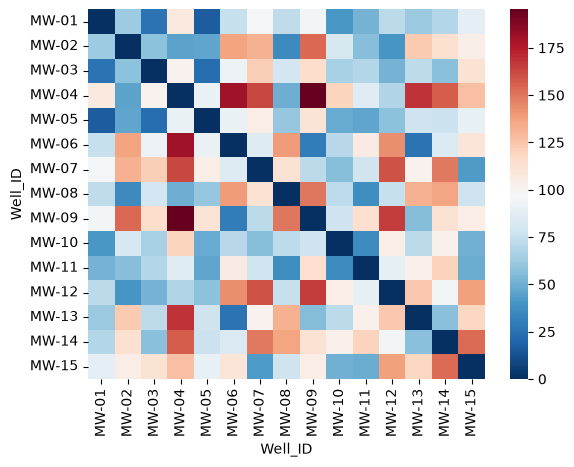

In [29]:
sns.heatmap(distance_df,cmap='RdBu_r')

In [30]:
well_ids = df["Well_ID"].to_numpy()

# Ignore self-distances when searching for the closest pair.
distance_without_diagonal = distance_matrix.copy()
np.fill_diagonal(distance_without_diagonal, np.inf)

closest_indices = np.unravel_index(
    np.argmin(distance_without_diagonal),
    distance_matrix.shape,
)

farthest_indices = np.unravel_index(
    np.argmax(distance_matrix),
    distance_matrix.shape,
)

print(
    "Closest pair:",
    well_ids[closest_indices[0]],
    well_ids[closest_indices[1]],
    f"{distance_matrix[closest_indices]:.2f} m",
)

print(
    "Farthest pair:",
    well_ids[farthest_indices[0]],
    well_ids[farthest_indices[1]],
    f"{distance_matrix[farthest_indices]:.2f} m",
)

Closest pair: MW-01 MW-05 16.48 m
Farthest pair: MW-04 MW-09 195.33 m


In [31]:
nearest_indices = np.argmin(
    distance_without_diagonal,
    axis=1,
)

nearest_distances = distance_without_diagonal[
    np.arange(len(df)),
    nearest_indices,
]

nearest_neighbor_df = pd.DataFrame(
    {
        "Well_ID": well_ids,
        "Nearest_Well": well_ids[nearest_indices],
        "Distance_m": nearest_distances,
    }
)

nearest_neighbor_df.sort_values("Distance_m")

,Well_ID,Nearest_Well,Distance_m
0,MW-01,MW-05,16.483204
4,MW-05,MW-01,16.483204
2,MW-03,MW-05,22.904535
5,MW-06,MW-13,25.879868
12,MW-13,MW-06,25.879868
8,MW-09,MW-06,29.385087
7,MW-08,MW-02,35.605107
1,MW-02,MW-08,35.605107
10,MW-11,MW-10,36.242395
9,MW-10,MW-11,36.242395


In [32]:
def nearest_neighbor_diagnostics(
    distance_matrix,
    well_ids,
):
    distances = distance_matrix.copy()

    # Exclude each well's distance to itself.
    np.fill_diagonal(distances, np.inf)
    # Find the column containing each row's minimum.
    nearest_indices = np.argmin(distances, axis=1)
    # Retrieve those minimum distances.
    nearest_distances = np.min(distances, axis=1)
    # Making sure positional NumPy indexing works.
    well_ids = np.asarray(well_ids)
    results = pd.DataFrame(
        {
            "Well_ID": well_ids,
            "Nearest_Well": well_ids[nearest_indices],
            "Distance_m": nearest_distances,
        }
    )

    return results

nearest_neighbors = nearest_neighbor_diagnostics(
    distance_matrix,
    df["Well_ID"],
)

nearest_neighbors

,Well_ID,Nearest_Well,Distance_m
0,MW-01,MW-05,16.483204
1,MW-02,MW-08,35.605107
2,MW-03,MW-05,22.904535
3,MW-04,MW-02,45.306586
4,MW-05,MW-01,16.483204
5,MW-06,MW-13,25.879868
6,MW-07,MW-15,42.517743
7,MW-08,MW-02,35.605107
8,MW-09,MW-06,29.385087
9,MW-10,MW-11,36.242395


In [33]:
nearest_neighbors = nearest_neighbor_diagnostics(
    distance_matrix,
    df["Well_ID"],
)

nearest_neighbors.sort_values("Distance_m")

,Well_ID,Nearest_Well,Distance_m
0,MW-01,MW-05,16.483204
4,MW-05,MW-01,16.483204
2,MW-03,MW-05,22.904535
5,MW-06,MW-13,25.879868
12,MW-13,MW-06,25.879868
8,MW-09,MW-06,29.385087
7,MW-08,MW-02,35.605107
1,MW-02,MW-08,35.605107
10,MW-11,MW-10,36.242395
9,MW-10,MW-11,36.242395


In [34]:
nearest_neighbors["Distance_m"].describe()

count    15.000000
mean     33.868668
std      11.159126
min      16.483204
25%      25.879868
50%      35.605107
75%      41.235886
max      57.023147
Name: Distance_m, dtype: float64

In [35]:
closest = nearest_neighbors.loc[
    nearest_neighbors["Distance_m"].idxmin()
]

most_isolated = nearest_neighbors.loc[
    nearest_neighbors["Distance_m"].idxmax()
]

print(closest)
print(most_isolated)

Well_ID             MW-01
Nearest_Well        MW-05
Distance_m      16.483204
Name: 0, dtype: object
Well_ID             MW-14
Nearest_Well        MW-03
Distance_m      57.023147
Name: 13, dtype: object


Task was destroyed but it is pending!
task: <Task pending name='Task-3' coro=<_async_in_context.<locals>.run_in_context() running at /home/chema/miniforge3/envs/openplumes/lib/python3.12/site-packages/ipykernel/utils.py:60> wait_for=<Task pending name='Task-5' coro=<Kernel.shell_main() running at /home/chema/miniforge3/envs/openplumes/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/chema/miniforge3/envs/openplumes/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-2' coro=<Kernel.shell_main() running at /home/chema/miniforge3/envs/openplumes/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
/home/chema/miniforge3/envs/openplumes/lib/python3.12/site-packages/matplotlib/transforms.py:193: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destro

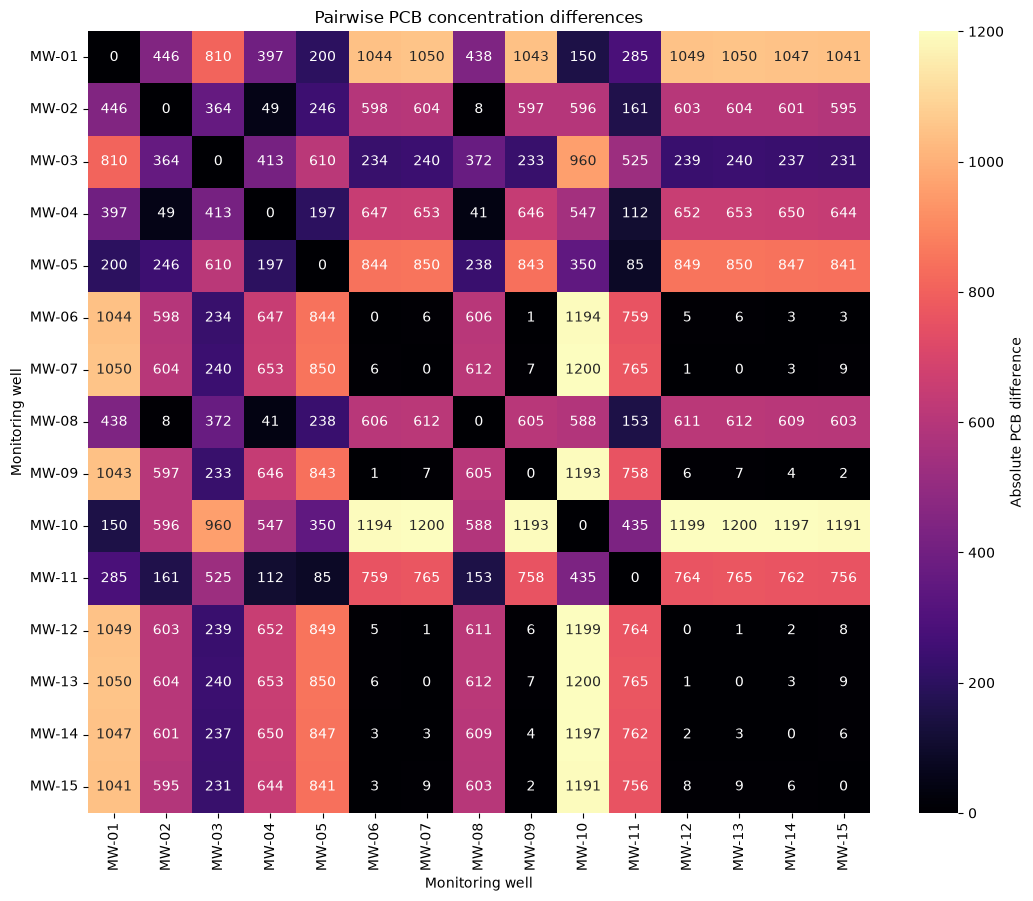

In [36]:
# Create pairwise absolute PCB concentration differences.
concentrations = df["PCB"].to_numpy(dtype=float)
well_ids = df["Well_ID"].to_numpy()

concentration_difference = np.abs(
    concentrations[:, None] - concentrations[None, :]
)

# Convert the matrix into a labeled DataFrame.
concentration_difference_df = pd.DataFrame(
    concentration_difference,
    index=well_ids,
    columns=well_ids,
)

# Plot the heatmap.
fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    concentration_difference_df,
    cmap="magma",
    annot=True,
    fmt=".0f",
    square=True,
    cbar_kws={"label": "Absolute PCB difference"},
    ax=ax,
)

ax.set_title("Pairwise PCB concentration differences")
ax.set_xlabel("Monitoring well")
ax.set_ylabel("Monitoring well")

fig.tight_layout()
plt.show()

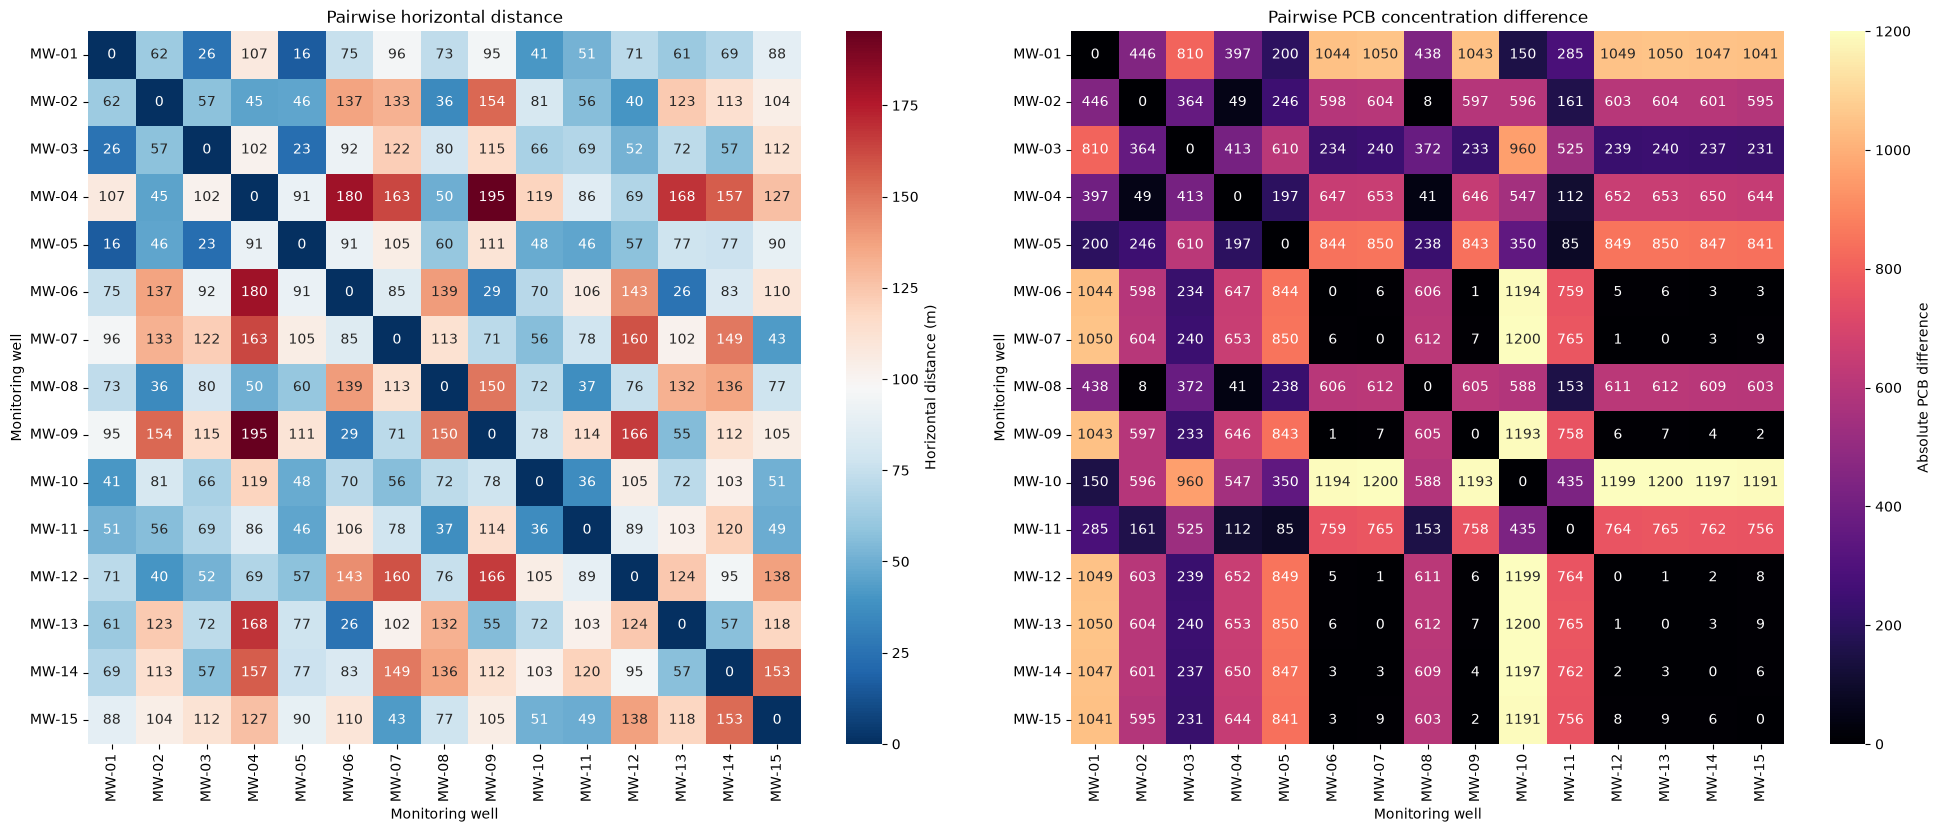

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    distance_df,
    cmap="RdBu_r",
    annot=True,
    fmt=".0f",
    square=True,
    cbar_kws={"label": "Horizontal distance (m)"},
    ax=axes[0],
)

axes[0].set_title("Pairwise horizontal distance")
axes[0].set_xlabel("Monitoring well")
axes[0].set_ylabel("Monitoring well")

sns.heatmap(
    concentration_difference_df,
    cmap="magma",
    annot=True,
    fmt=".0f",
    square=True,
    cbar_kws={"label": "Absolute PCB difference"},
    ax=axes[1],
)

axes[1].set_title("Pairwise PCB concentration difference")
axes[1].set_xlabel("Monitoring well")
axes[1].set_ylabel("Monitoring well")

fig.tight_layout()
plt.show()

### Making the model

In [38]:
### my version
#test = 'test/test/test/test.dbf'
#test2 = 'test/test/test/test.shp.anything'

def boundary_conditions_from_File(boundaries_path):
    list_of_accepted_formats = ['shp']

    check = boundaries_path.split('.')
    
    if len(check)!= 2:
        raiseValueError(boundaries_path, 'not a valid file type')
        
    check2 = boundaries_path.split('.')[-1]
    
    if check2 not in list_of_accepted_formats:
        raiseValueError(check2,' is not a format we currently support')

    # open shape file
    # get coordinates
    # validate coordiantes function (aka check if convex hull and if a rectangle etc...)
    # return boundary inputs for mesh
    

def boundary_conditions_not_from_File():
     # validate coordiantes function (aka check if convex hull and if a rectangle etc...)
     # return boundary inputs for mesh
     


def boundary_conditions(boundaries):
    if os.path.isfile(boundaries):
       shape = boundary_condition_from_file(boundaries)

    else:
        raiseValueError(from_file + 'Is not a valid file path... check again.'

    if type(boundaries) is list:
        if all(isinstance(values, (int, float)) for x in boundaries):
            shape=boundary_conditions_not_from_File(boundaries)

        else:
            invalid_value = [x for x in from_file if atype(x) not int and float)]:
            raiseValueError("in boundaries:" boundaries, invalid_value, "Is or are not valid inputs check if it is a string?")
    else:
        raiseValueError('the variable set as boundaries is not a list. Needs to be a list')

    return shape
        
            
        

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (1182770051.py, line 42)

In [39]:
### chats version
from pathlib import Path
import geopandas as gpd
import numpy as np

# maybe edit this so it takes in multiple data types, like if bouds is str, list, etc...
# so that there are less functions
def validate_bounds(bounds):
    """Validate and return six numeric 3D domain bounds."""

    expected_format = ("[x_min, x_max, y_min, y_max, z_min, z_max]")

    if not isinstance(bounds, (list, tuple, np.ndarray)):
        raise TypeError(
            "Manual domain bounds must be supplied as a list, "
            "tuple, or NumPy array.\n"
            f"Received type: {type(bounds).__name__}\n"
            f"Expected format: {expected_format}\n"
            "Example: [445020, 445180, 4046750, 4046910, -110, -20]"
        )

    if len(bounds) != 6:
        raise ValueError(
            "Manual domain bounds require exactly six values.\n"
            f"Received {len(bounds)} values: {bounds}\n"
            f"Expected format: {expected_format}"
        )

    invalid_values = [value for value in bounds if not isinstance(value, (int, float, np.number))]

    if invalid_values:
        raise TypeError(
            "Every domain-bound value must be numeric.\n"
            f"Invalid values: {invalid_values}\n"
            f"Received bounds: {bounds}\n"
            f"Expected format: {expected_format}"
        )

    bounds = np.asarray(bounds, dtype=float)

    if not np.isfinite(bounds).all():
        invalid_positions = np.flatnonzero(
            ~np.isfinite(bounds)
        ).tolist()

        raise ValueError(
            "Domain bounds contain NaN or infinite values.\n"
            f"Invalid positions: {invalid_positions}\n"
            f"Received bounds: {bounds.tolist()}"
        )

    x_min, x_max, y_min, y_max, z_min, z_max = bounds

    if x_min >= x_max:
        raise ValueError(
            "Invalid X bounds.\n"
            f"Received x_min={x_min:g} and x_max={x_max:g}.\n"
            "x_min must be smaller than x_max.\n"
            f"Expected format: {expected_format}"
        )

    if y_min >= y_max:
        raise ValueError(
            "Invalid Y bounds.\n"
            f"Received y_min={y_min:g} and y_max={y_max:g}.\n"
            "y_min must be smaller than y_max.\n"
            f"Expected format: {expected_format}"
        )

    if z_min >= z_max:
        raise ValueError(
            "Invalid Z bounds.\n"
            f"Received z_min={z_min:g} and z_max={z_max:g}.\n"
            "z_min must be smaller than z_max.\n"
            "If depth is represented as negative Z, a valid example "
            "is z_min=-110 and z_max=-20."
        )

    return {
        "x_min": float(x_min),
        "x_max": float(x_max),
        "y_min": float(y_min),
        "y_max": float(y_max),
        "z_min": float(z_min),
        "z_max": float(z_max),
    }


def domain_bounds_from_values(boundaries):
    """Create domain bounds from six manually supplied values."""

    return validate_bounds(boundaries)


def domain_bounds_from_file(
    boundaries_path,
    z_bounds,
    model_crs,
):
    """Read horizontal bounds from a polygon boundary file."""

    path = Path(boundaries_path)
    accepted_formats = {".shp"}

    if not path.is_file():
        raise FileNotFoundError(
            "The model-boundary file could not be found.\n"
            f"Received path: {path}\n"
            "Check the spelling, directory, and file extension."
        )

    if path.suffix.lower() not in accepted_formats:
        raise ValueError(
            "The model-boundary file format is not currently supported.\n"
            f"Received extension: {path.suffix or '[no extension]'}\n"
            f"Supported extensions: {sorted(accepted_formats)}\n"
            "Convert the boundary to a supported format and try again."
        )

    if z_bounds is None:
        raise ValueError(
            "Vertical bounds are required when loading a horizontal "
            "boundary file.\n"
            "Expected format: z_bounds=(z_min, z_max)\n"
            "Example: z_bounds=(-110, -20)"
        )

    try:
        boundary_data = gpd.read_file(path)
    except Exception as error:
        raise RuntimeError(
            "The model-boundary file exists but could not be read.\n"
            f"File: {path}\n"
            "For a shapefile, confirm that its companion files such as "
            ".dbf and .shx are present in the same directory."
        ) from error

    if boundary_data.empty:
        raise ValueError(
            "The model-boundary file contains no features.\n"
            f"File: {path}\n"
            "Add at least one polygon feature before using this file."
        )

    if boundary_data.crs is None:
        raise ValueError(
            "The model-boundary file does not declare a CRS.\n"
            f"File: {path}\n"
            "OpenPlumes cannot safely combine this boundary with projected "
            "well coordinates until its CRS is known."
        )

    valid_geometry_types = {"Polygon", "MultiPolygon"}

    invalid_geometry_types = sorted(
        set(boundary_data.geom_type)
        - valid_geometry_types
    )

    if invalid_geometry_types:
        raise ValueError(
            "The model-boundary file must contain polygon geometry.\n"
            f"Invalid geometry types found: {invalid_geometry_types}\n"
            "Use a Polygon or MultiPolygon boundary."
        )

    if not boundary_data.geometry.is_valid.all():
        invalid_count = int(
            (~boundary_data.geometry.is_valid).sum()
        )

        raise ValueError(
            "The model-boundary file contains invalid geometry.\n"
            f"Number of invalid features: {invalid_count}\n"
            "Repair the polygon geometry before creating the model grid."
        )

    if model_crs is None:
        raise ValueError(
            "A projected modeling CRS is required when loading a "
            "boundary file.\n"
            "Example: model_crs='EPSG:32613'"
        )

    # Transform the boundary into the same CRS as the modeling coordinates.
    boundary_data = boundary_data.to_crs(model_crs)

    x_min, y_min, x_max, y_max = boundary_data.total_bounds
    z_min, z_max = z_bounds

    bounds = [
        x_min,
        x_max,
        y_min,
        y_max,
        z_min,
        z_max,
    ]

    return validate_bounds(bounds)


def get_domain_bounds(
    boundaries,
    z_bounds=None,
    model_crs=None,
):
    """
    Create 3D domain bounds from either a boundary file or manual values.

    File input:
        boundaries="model_boundary.shp"
        z_bounds=(-110, -20)
        model_crs="EPSG:32613"

    Manual input:
        boundaries=[
            x_min,
            x_max,
            y_min,
            y_max,
            z_min,
            z_max,
        ]
    """

    if isinstance(boundaries, (str, Path)):
        return domain_bounds_from_file(
            boundaries_path=boundaries,
            z_bounds=z_bounds,
            model_crs=model_crs,
        )

    if isinstance(boundaries, (list, tuple, np.ndarray)):
        return domain_bounds_from_values(boundaries)

    raise TypeError(
        "OpenPlumes could not interpret the domain-boundary input.\n"
        f"Received type: {type(boundaries).__name__}\n"
        "Supply either:\n"
        "1. A boundary-file path, such as 'model_boundary.shp'; or\n"
        "2. Six numeric values in this order:\n"
        "   [x_min, x_max, y_min, y_max, z_min, z_max]"
    )

In [40]:
boundary_path = ("/mnt/c/Users/josem/OneDrive/Documents/Dummy_data/model_domain/shape_file/model_domain.shp")

bounds = get_domain_bounds(
    boundaries=boundary_path,
    z_bounds=(-110, -20),
    model_crs=model_crs,
)

bounds

{'x_min': 445023.79846232856,
 'x_max': 445182.4117923286,
 'y_min': 4046758.2586032576,
 'y_max': 4046918.9797532577,
 'z_min': -110.0,
 'z_max': -20.0}

In [50]:
model_crs

<Projected CRS: EPSG:32613>
Name: WGS 84 / UTM zone 13N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 108°W and 102°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Northwest Territories (NWT); Nunavut; Saskatchewan. Mexico. United States (USA).
- bounds: (-108.0, 0.0, -102.0, 84.0)
Coordinate Operation:
- name: UTM zone 13N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Making and fitting the model

In [41]:
from scipy.interpolate import RBFInterpolator

def interpolateRBF(xyz_points, contaminant, kernel, neighbors_num, epsilon_num):
    
    rbf_fit = RBFInterpolator(
        xyz_points, 
        contaminant,
        kernel = kernel, # make sure this is eventuallyh a global variable
        neighbors = neighbors_num,
        epsilon=epsilon_num,
        )

    return rbf_fit
        
neighbors_num = None
epsilon_num = .001
contaminant = 'PCB'

model_fit = interpolateRBF(xyz_points = pdata.points,
                           contaminant = pdata.point_data[contaminant],
                           kernel='thin_plate_spline',
                           neighbors_num = neighbors_num, 
                           epsilon_num = epsilon_num,
                          )



In [42]:
bounds

{'x_min': 445023.79846232856,
 'x_max': 445182.4117923286,
 'y_min': 4046758.2586032576,
 'y_max': 4046918.9797532577,
 'z_min': -110.0,
 'z_max': -20.0}

In [43]:
np.array([
round(bounds['x_max']-bounds['x_min']),
round(bounds['y_max']-bounds['y_min']),
round(bounds['z_max']-bounds['z_min'])
])

array([159, 161,  90])

In [44]:
def generate_grid(boundary, xyz_resolution):
    
    domain_min = np.array([
    round(boundary["x_min"]),
    round(boundary["y_min"]),
    round(boundary["z_min"]),
    ])
    
    domain_max = np.array([
        round(boundary["x_max"]),
        round(boundary["y_max"]),
        round(boundary["z_max"]),
    ])
    
    domain_span = domain_max - domain_min
    
    number_of_cells = np.ceil(domain_span / xyz_resolution).astype(int)
    
    # Include both endpoints.
    number_of_points = number_of_cells + 1
    
    # Adjust spacing so the grid ends exactly at domain_max.
    
    actual_spacing = domain_span / number_of_cells

    grid = pv.ImageData()

    ### diagnostics!!!!
    grid.dimensions = tuple(number_of_points)
    grid.origin = tuple(domain_min)
    grid.spacing = tuple(actual_spacing)

    return grid

requested_spacing = np.array([
                                5.0, #X meters
                                5.0, #Y meters
                                5.0  #Z meters
                            ])

grid = generate_grid(
                    boundary = bounds,
                    xyz_resolution = requested_spacing
                    )

In [45]:
grid
#grid.plot(show_edges=True)

ImageData (0x71d2b15f6740)
  N Cells:      19008
  N Points:     21318
  X Bounds:     4.450e+05, 4.452e+05
  Y Bounds:     4.047e+06, 4.047e+06
  Z Bounds:     -1.100e+02, -2.000e+01
  Dimensions:   33, 34, 19
  Spacing:      4.938e+00, 4.879e+00, 5.000e+00
  N Arrays:     0

In [46]:
prediction_points = grid.points
print(prediction_points.shape)

predicted_values = model_fit(prediction_points)
grid.point_data[contaminant] = predicted_values
print("Grid points:", grid.n_points)
print("Predictions:", len(predicted_values))
print("Minimum prediction:", predicted_values.min())
print("Maximum prediction:", predicted_values.max())
print("Negative predictions:", np.sum(predicted_values < 0))
print("Finite predictions:", np.isfinite(predicted_values).all())

(21318, 3)
Grid points: 21318
Predictions: 21318
Minimum prediction: -7382259.246063556
Maximum prediction: -7380799.903422309
Negative predictions: 21318
Finite predictions: True


In [47]:
grid.plot(
    scalars=contaminant,
    cmap="seismic",
    show_edges=False,
)

Widget(value='<iframe src="http://localhost:36753/index.html?ui=P_0x71d2c43d6ba0_1&reconnect=auto" class="pyvi…

In [48]:
isosurfaces = grid.contour(
    isosurfaces=[0, 500, 1000],
    scalars=contaminant,
)

2026-08-23 09:03:51.248 ( 161.208s) [        537FF600]            Contour.cxx:49    INFO| Using flying edges
2026-08-23 09:03:51.253 ( 161.214s) [        F17FA6C0]RuntimeDeviceInformatio:234   WARN| Initializing 'RuntimeDeviceConfigurations' with uninitialized configOptions. Did you call viskores::cont::Initialize?


In [49]:

neighbors_num = None
epsilon_num = .01
contaminant = 'PCB'

model_fit = interpolateRBF(xyz_points = pdata.points,
                           contaminant = pdata.point_data[contaminant],
                           kernel='thin_plate_spline',
                           neighbors_num = neighbors_num, 
                           epsilon_num = epsilon_num,
                          )

grid = generate_grid(
                    boundary = bounds,
                    xyz_resolution = requested_spacing
                    )

prediction_points = grid.points
predicted_values = model_fit(prediction_points)
grid.point_data[contaminant] = predicted_values

isosurfaces = grid.contour(
    isosurfaces=[0,1000],
    scalars=contaminant,
)
isosurfaces.plot(
    scalars=contaminant,
    cmap="turbo",
    show_edges=True,
)

sphere = pv.Sphere(radius=2, phi_resolution=10, theta_resolution=10)
pc = pdata.glyph(scale=False, geom=sphere, orient=False)
pc.plot(cmap='turbo')

2026-08-23 09:03:52.240 ( 162.201s) [        537FF600]            Contour.cxx:49    INFO| Using flying edges


ValueError: Empty meshes cannot be plotted. Input mesh has zero points. To allow plotting empty meshes, set `pv.global_theme.allow_empty_mesh = True`

In [ ]:
# Use one color range for both predicted and observed PCB.
color_limits = (
    min(grid[contaminant].min(), pdata[contaminant].min()),
    max(grid[contaminant].max(), pdata[contaminant].max()),
)

plotter = pv.Plotter()

# Add predicted isosurfaces.
plotter.add_mesh(
    isosurfaces,
    scalars=contaminant,
    cmap="turbo",
    clim=color_limits,
    show_edges=True,
    opacity=0.70,
    scalar_bar_args={"title": contaminant},
)

# Add observed monitoring wells.
plotter.add_mesh(
    pc,
    scalars=contaminant,
    cmap="turbo",
    clim=color_limits,
    show_scalar_bar=False,
)

plotter.add_axes()

plotter.show_grid(
    xlabel="Easting (m)",
    ylabel="Northing (m)",
    zlabel="Elevation relative to surface (m)",
)

plotter.show()

### Evaluating the model

In [ ]:
distance_df

In [ ]:
def generate_nearest_neighbor_profiles(well, k_neighbors=1, points_per_profile=50):
    "will genearate linear profiles in 3d to later be used in other tools"
    well_of_choice = well
    ordered_distances = ( 
        distance_df.loc[well_of_choice].drop(well_of_choice) # getting distances to well of choice and removing itself
        .sort_values() # sorting by numerical values so we have order of nearest neighbors
                    )
    # extracting the names of those wells
    well_names = ordered_distances.index.to_numpy()
    distances = ordered_distances.to_numpy()

    #retaining only the selected number of nearest neabohrs
    nearest = ordered_distances.head(k_neighbors)
    neighbor_names = nearest.index.to_numpy()
    neighbor_distances = nearest.to_numpy()

    profile_points =  get_k_profile_points(well_of_choice,
                                           neighbor_names,
                                           neighbor_distances,
                                           points_per_profile)

    profile_predict = predict_profile_points(model_fit, profile_points, neighbor_names)

    print(neighbor_names)#, neighbor_distances[0])
    print()
    print()
    print(profile_points)

    return profile_points, profile_predict
    
    

profile_points, profile_predictions = generate_nearest_neighbor_profiles(well = 'MW-10',k_neighbors = 5, points_per_profile=10)

In [ ]:
profile_predictions

In [ ]:
df.loc[df["Well_ID"] == well]

In [ ]:
points = 3

In [ ]:
def get_k_profile_points(well_a, nearest_k, nearest_dist, points):
    t = np.linspace(0, 1, points)
    export = {}
    well_data_a = df.loc[
            df["Well_ID"] == well_a
        ]
    
    xa = well_data_a["X"].to_numpy()[0]
    ya = well_data_a["Y"].to_numpy()[0]
    za = -well_data_a["depth"].to_numpy()[0]

    # getting starting point (well of choice)
    start_point = np.array([
        xa,
        ya,
        za,
    ])
    
    for well, dist in zip(nearest_k, nearest_dist):

        # getting end point (nearest neighbor)
        well_data_b = df.loc[
            df["Well_ID"] == well
        ]
    
        xb = well_data_b["X"].to_numpy()[0]
        yb = well_data_b["Y"].to_numpy()[0]
        zb = -well_data_b["depth"].to_numpy()[0]
    
        end_point = np.array([
            xb,
            yb,
            zb,
        ])
    
        profile_points = (
            start_point
            + t[:, None] * (end_point - start_point)
        )

        export[well] = profile_points
        
    return export
     

#test = test_func(test_well,test_nearest,test_dist,points)
 

In [ ]:
def predict_profile_points(model, profile_dict, neighbors):
    scalar_dict = {}
    for neighbor in neighbors:
        print(neighbor)
        predict = model(profile_dict[neighbor])
        scalar_dict[neighbor] = predict
    
    return scalar_dict
        
    

#profile_predict = predict_profile_points(model_fit, profile,test)

In [ ]:
profile_points

In [ ]:
profile_predictions.keys()

In [ ]:
def add_profiles_to_plot(plot, dict_profile_coordinates, dict_profile_predictions,linewidth=0.05):
    
    for neighbor in dict_profile_predictions.keys():
        profile_plotter = pv.Plotter()
        
        points = dict_profile_coordinates[neighbor]
        predictions = dict_profile_predictions[neighbor]

        line = pv.MultipleLines(points)
        line['PCB'] = predictions # ***NEEDS TO BE REPLACED WITH A MORE GLOBAL VARIABLE! ***
        
        tube = line.tube(
            radius=linewidth,
            radius_factor=1.0,  # Prevent scalar-dependent thickness
        )
        
        plot.add_mesh(tube, scalars='PCB', cmap='turbo')

    return plot

plotter_profiles = add_profiles_to_plot(plotter, profile_points, profile_predictions, linewidth=1.0)

In [ ]:
well_data = df.loc[df["Well_ID"] == well]
well_data['X'].to_numpy()[0]

In [ ]:
d

In [ ]:
distances_from_well = distance_df.loc[well_of_choice]
distances_from_well

In [ ]:
# gives distances between 2 selected wells distance_df.loc["MW-10", "MW-05"]

In [ ]:
requested_spacing = np.array([5.0, 5.0, 5.0])

domain_min = np.array([
    bounds["x_min"],
    bounds["y_min"],
    bounds["z_min"],
])

domain_max = np.array([
    bounds["x_max"],
    bounds["y_max"],
    bounds["z_max"],
])

domain_span = domain_max - domain_min

# Round upward so the cells cover the domain.
number_of_cells = np.ceil(
    domain_span / requested_spacing
).astype(int)

# Include both endpoints.
number_of_points = number_of_cells + 1

# Adjust spacing so the grid ends exactly at domain_max.
actual_spacing = domain_span / number_of_cells

In [ ]:
grid = pv.ImageData()

grid.dimensions = tuple(number_of_points)
grid.origin = tuple(domain_min)
grid.spacing = tuple(actual_spacing)

#grid.plot(show_edges=True)

In [ ]:
print("Domain span:", domain_span)
print("Requested spacing:", requested_spacing)
print("Actual spacing:", np.array(grid.spacing))
print("Grid dimensions:", grid.dimensions)
print("Number of points:", grid.n_points)
print("Number of cells:", grid.n_cells)
print("Grid bounds:", grid.bounds)

In [ ]:
pwd

In [ ]:
### use function above. this was to help create function

from pyproj import CRS, Transformer
from scipy.spatial.distance import pdist, squareform

# defining strings in case different spreadsheets have different
# variable names
Longitude = 'long'
Latitude = 'lat'

# Define the source and modeling coordinate systems.
source_crs = CRS.from_epsg(4326)   # WGS 84 longitude/latitude
model_crs = CRS.from_epsg(32613)  # WGS 84 / UTM Zone 13N

# Building the coordinate transformer
transformer = Transformer.from_crs(
    source_crs,
    model_crs,
    always_xy = True,
)

# Creating X and Y variables that will have new projected coordinates
df['X'], df['Y'] = transformer.transform(
    df[Longitude].to_numpy(),
    df[Latitude].to_numpy()
)
# doing the same for log transformed data set we created. Just in case!
df_log['X'], df['Y'] = transformer.transform(
    df[Longitude].to_numpy(),
    df[Latitude].to_numpy()
)